# Session 15 Worksheet: Gaussian Elimination

## Objective
To apply **Gaussian Elimination** to solve a system of linear equations derived from a real-world engineering context (e.g., stress analysis in a material structure).

---

## Background

**Gaussian Elimination** is a method for solving systems of linear equations. It involves performing **row operations** to convert the matrix into an **upper triangular form**, followed by **back-substitution** to determine the variable values.

---

## Problem Statement

You are given a system of 3 equations representing stress components in a material under load. Solve the following system using **Gaussian Elimination**:

\[
\begin{aligned}
2x + 3y + z &= 1 \\
4x + y + 2z &= 2 \\
-2x + 5y - z &= 0
\end{aligned}
\]
Instructions:
- 1. Convert the system into an augmented matrix.
- 2. Use row operations to form an upper triangular matrix.
- 3. Perform back-substitution to find the values of x, y, and z.
- 4. Show each step of your row operations clearly.
- 5. Verify your result by plugging the solution into the original equations.


🚀 STARTING DETAILED GAUSSIAN ELIMINATION

📋 INITIAL SYSTEM:

Current Augmented Matrix [A|b]:
      x    y    z  constant
R1  2.0  3.0  1.0       1.0
R2  4.0  1.0  2.0       2.0
R3 -2.0  5.0 -1.0       0.0

🎯 FORWARD ELIMINATION PHASE
Goal: Transform the matrix into upper triangular form
Strategy: Work column by column, left to right


==================== COLUMN 1 ELIMINATION ====================

🎯 CHOOSING PIVOT FOR COLUMN 1
----------------------------------------
Row 1 candidate: 2.0
Row 2 candidate: 4.0
Row 3 candidate: -2.0

💡 STRATEGY: Choose largest absolute value to minimize errors
Best pivot: Row 2 with value 4.0
Absolute value: 4.0

🔄 DECISION: Swap Row 1 ↔ Row 2

🔄 ROW SWAP OPERATION
Swapping Row 1 ↔ Row 2
Before:
  Row 1: [2. 3. 1. 1.]
  Row 2: [4. 1. 2. 2.]
After:
  Row 1: [4. 1. 2. 2.]
  Row 2: [2. 3. 1. 1.]


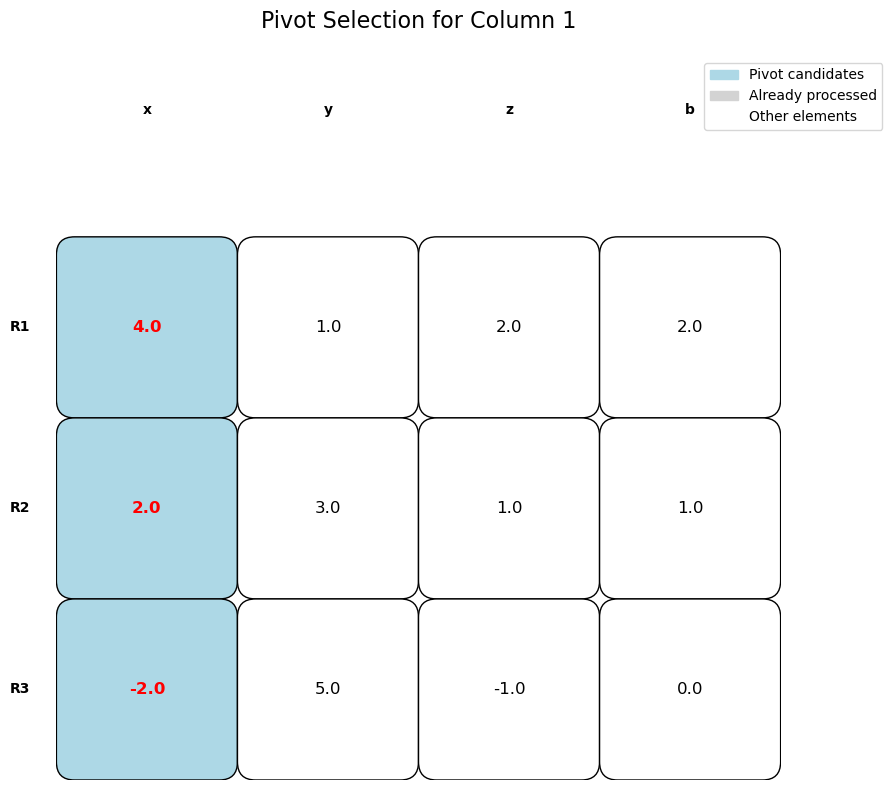


🎬 ELIMINATION PHASE FOR COLUMN 1

🎯 ELIMINATING ELEMENT AT ROW 2, COLUMN 1
--------------------------------------------------
Current values:
  - Pivot (Row 1): 4.0
  - Target (Row 2): 2.0

🔢 CALCULATION:
  - We want to make Row 2, Column 1 = 0
  - Factor needed: -2.0/4.0 = -0.5
  - Operation: Row 2 = Row 2 + (-0.500) × Row 1

💭 WHY THIS WORKS:
  - When we add -0.500 × 4.0 to 2.0
  - We get: 2.0 + (-0.500 × 4.0) = 0

🔄 ROW TRANSFORMATION:
  Old Row 2: [2. 3. 1. 1.]
  Multiplier × Row 1: -0.500 × [4. 1. 2. 2.]
  New Row 2: [0.  2.5 0.  0. ]

📊 CURRENT MATRIX STATE:

Current Augmented Matrix [A|b]:
      x    y    z  constant
R1  4.0  1.0  2.0       2.0
R2  0.0  2.5  0.0       0.0
R3 -2.0  5.0 -1.0       0.0

🎯 ELIMINATING ELEMENT AT ROW 3, COLUMN 1
--------------------------------------------------
Current values:
  - Pivot (Row 1): 4.0
  - Target (Row 3): -2.0

🔢 CALCULATION:
  - We want to make Row 3, Column 1 = 0
  - Factor needed: --2.0/4.0 = 0.5
  - Operation: Row 3 = Row 3 + (0.5

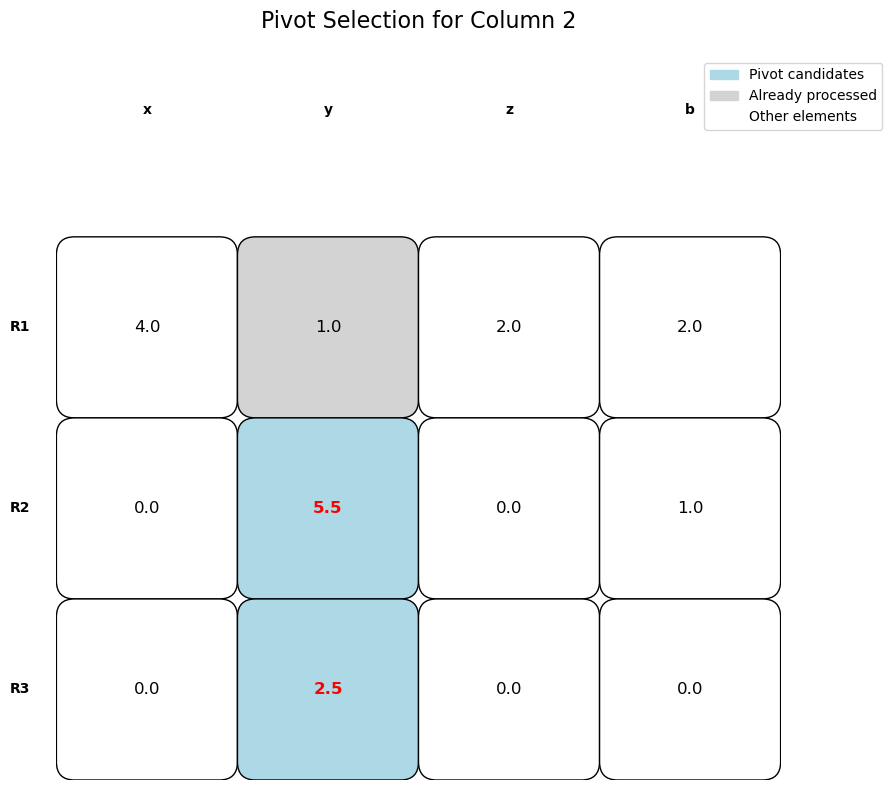


🎬 ELIMINATION PHASE FOR COLUMN 2

🎯 ELIMINATING ELEMENT AT ROW 3, COLUMN 2
--------------------------------------------------
Current values:
  - Pivot (Row 2): 5.5
  - Target (Row 3): 2.5

🔢 CALCULATION:
  - We want to make Row 3, Column 2 = 0
  - Factor needed: -2.5/5.5 = -0.45454545454545453
  - Operation: Row 3 = Row 3 + (-0.455) × Row 2

💭 WHY THIS WORKS:
  - When we add -0.455 × 5.5 to 2.5
  - We get: 2.5 + (-0.455 × 5.5) = 0

🔄 ROW TRANSFORMATION:
  Old Row 3: [0.  2.5 0.  0. ]
  Multiplier × Row 2: -0.455 × [0.  5.5 0.  1. ]
  New Row 3: [ 0.          0.          0.         -0.45454545]

📊 CURRENT MATRIX STATE:

Current Augmented Matrix [A|b]:
      x    y    z  constant
R1  4.0  1.0  2.0  2.000000
R2  0.0  5.5  0.0  1.000000
R3  0.0  0.0  0.0 -0.454545


==================== COLUMN 3 ELIMINATION ====================

🎯 CHOOSING PIVOT FOR COLUMN 3
----------------------------------------
Row 3 candidate: 0.0

💡 STRATEGY: Choose largest absolute value to minimize errors
Best pi

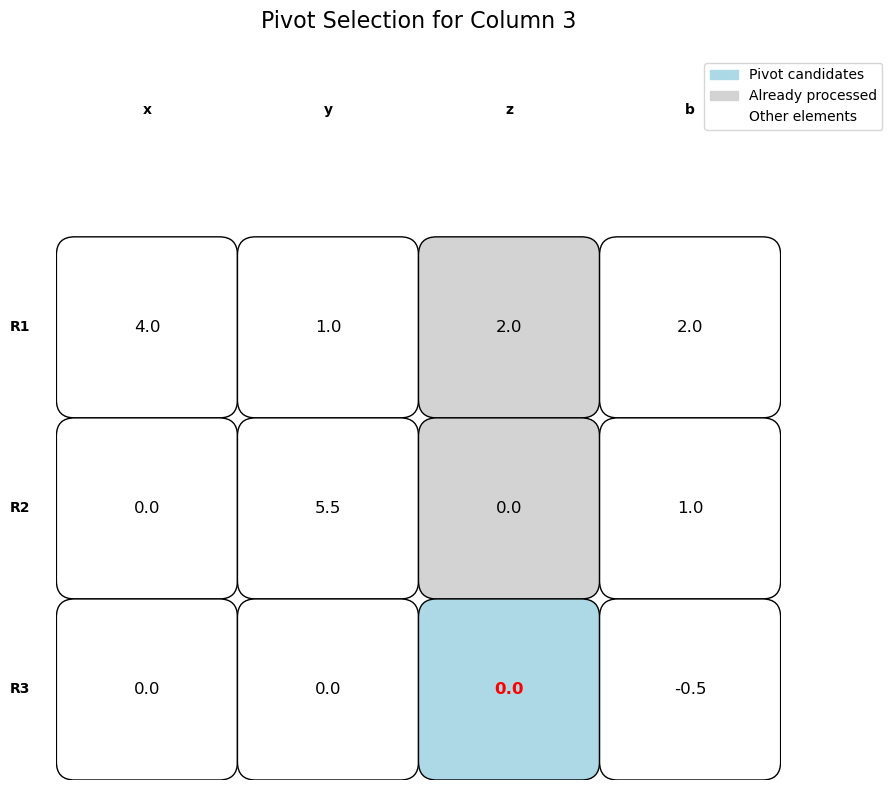


🎬 ELIMINATION PHASE FOR COLUMN 3


🏁 FORWARD ELIMINATION COMPLETE!

Current Augmented Matrix [A|b]:
      x    y    z  constant
R1  4.0  1.0  2.0  2.000000
R2  0.0  5.5  0.0  1.000000
R3  0.0  0.0  0.0 -0.454545

❌ INCONSISTENCY DETECTED!
Row 3: [ 0.          0.          0.         -0.45454545]
This translates to: 0x + 0y + 0z = constant
Which means: 0 = -0.45454545454545453

💭 INTERPRETATION:
- This equation is impossible to satisfy
- The system has NO SOLUTION
- In engineering terms: Conflicting constraints


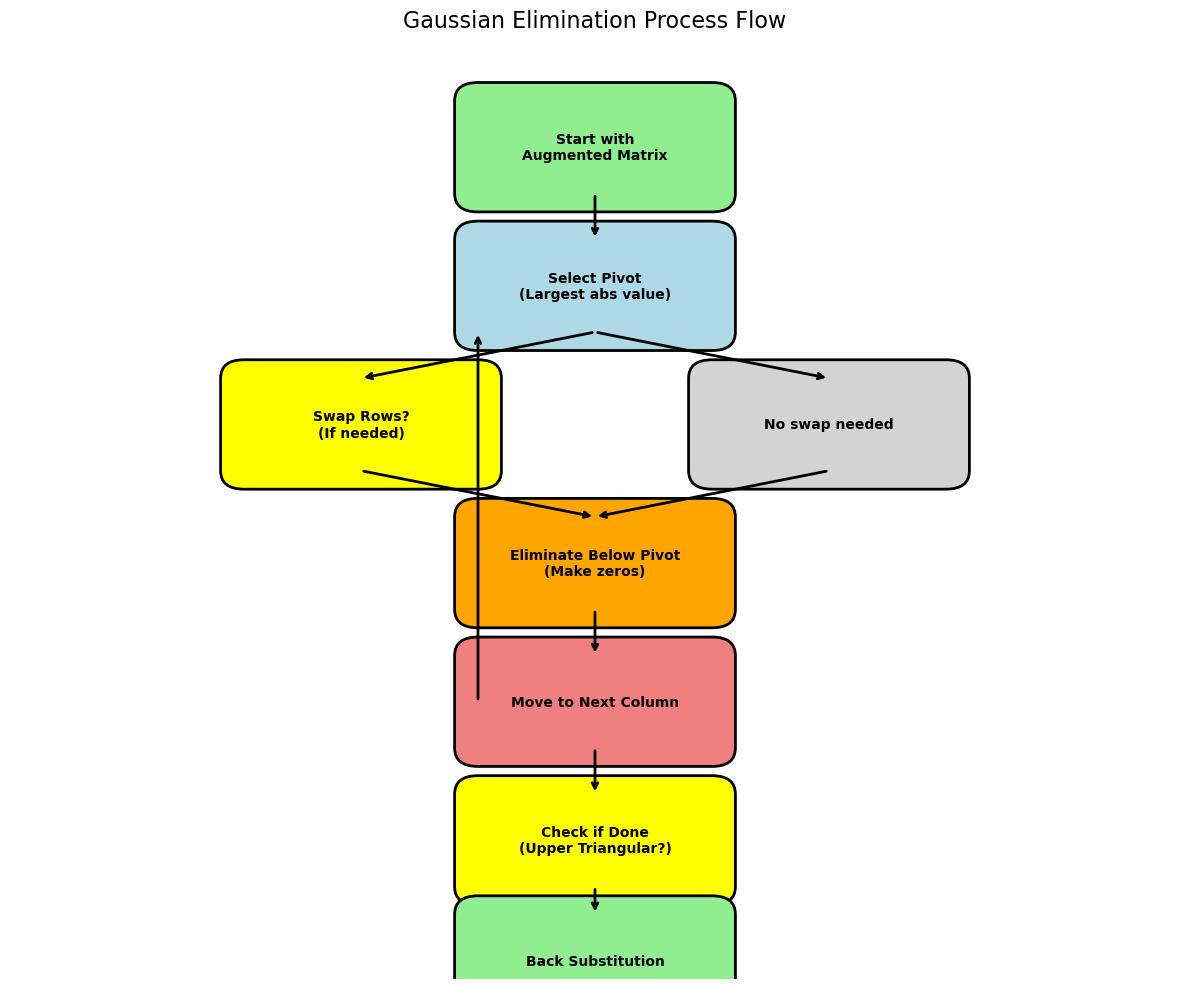

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

class DetailedGaussianElimination:
    def __init__(self, A, b):
        self.n = len(A)
        self.augmented = np.column_stack((A, b)).astype(float)
        self.original = self.augmented.copy()
        self.steps = []
        self.explanations = []
        
    def explain_pivot_choice(self, column):
        """Explain why we choose a particular pivot element"""
        print(f"\n🎯 CHOOSING PIVOT FOR COLUMN {column+1}")
        print("-" * 40)
        
        # Show all candidates in this column
        candidates = []
        for i in range(column, self.n):
            value = self.augmented[i, column]
            candidates.append((i, value))
            print(f"Row {i+1} candidate: {value}")
        
        # Find the best pivot (largest absolute value)
        best_row = column
        best_value = abs(self.augmented[column, column])
        
        for i in range(column+1, self.n):
            current_abs = abs(self.augmented[i, column])
            if current_abs > best_value:
                best_value = current_abs
                best_row = i
        
        print(f"\n💡 STRATEGY: Choose largest absolute value to minimize errors")
        print(f"Best pivot: Row {best_row+1} with value {self.augmented[best_row, column]}")
        print(f"Absolute value: {abs(self.augmented[best_row, column])}")
        
        if best_row != column:
            print(f"\n🔄 DECISION: Swap Row {column+1} ↔ Row {best_row+1}")
        else:
            print(f"\n✓ DECISION: Keep current row order")
        
        return best_row
    
    def explain_elimination_step(self, target_row, pivot_row, column):
        """Explain why and how we eliminate a specific element"""
        print(f"\n🎯 ELIMINATING ELEMENT AT ROW {target_row+1}, COLUMN {column+1}")
        print("-" * 50)
        
        pivot_value = self.augmented[pivot_row, column]
        target_value = self.augmented[target_row, column]
        
        print(f"Current values:")
        print(f"  - Pivot (Row {pivot_row+1}): {pivot_value}")
        print(f"  - Target (Row {target_row+1}): {target_value}")
        
        if abs(target_value) < 1e-10:
            print(f"\n✓ Already zero! No elimination needed.")
            return
        
        # Calculate the multiplier
        multiplier = -target_value / pivot_value
        
        print(f"\n🔢 CALCULATION:")
        print(f"  - We want to make Row {target_row+1}, Column {column+1} = 0")
        print(f"  - Factor needed: -{target_value}/{pivot_value} = {multiplier}")
        print(f"  - Operation: Row {target_row+1} = Row {target_row+1} + ({multiplier:.3f}) × Row {pivot_row+1}")
        
        print(f"\n💭 WHY THIS WORKS:")
        print(f"  - When we add {multiplier:.3f} × {pivot_value} to {target_value}")
        print(f"  - We get: {target_value} + ({multiplier:.3f} × {pivot_value}) = 0")
        
        # Show the actual row operation
        old_row = self.augmented[target_row].copy()
        new_row = old_row + multiplier * self.augmented[pivot_row]
        
        print(f"\n🔄 ROW TRANSFORMATION:")
        print(f"  Old Row {target_row+1}: {old_row}")
        print(f"  Multiplier × Row {pivot_row+1}: {multiplier:.3f} × {self.augmented[pivot_row]}")
        print(f"  New Row {target_row+1}: {new_row}")
        
        return multiplier
    
    def visualize_pivot_selection(self, column):
        """Create a visual representation of pivot selection process"""
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        
        # Create the matrix visualization
        matrix_display = self.augmented.copy()
        
        # Highlight the column we're working on
        for i in range(self.n):
            for j in range(self.n + 1):
                if j == column:
                    color = 'lightblue' if i >= column else 'lightgray'
                else:
                    color = 'white'
                
                rect = FancyBboxPatch((j-0.4, self.n-1-i-0.4), 0.8, 0.8,
                                    boxstyle="round,pad=0.1", facecolor=color,
                                    edgecolor='black', linewidth=1)
                ax.add_patch(rect)
                
                # Add value
                value = matrix_display[i, j]
                text_color = 'red' if (j == column and i >= column) else 'black'
                weight = 'bold' if (j == column and i >= column) else 'normal'
                ax.text(j, self.n-1-i, f'{value:.1f}', ha='center', va='center',
                       color=text_color, fontsize=12, weight=weight)
        
        # Add labels
        ax.set_xlim(-0.5, self.n + 0.5)
        ax.set_ylim(-0.5, self.n + 0.5)
        ax.set_aspect('equal')
        
        # Column headers
        headers = ['x', 'y', 'z', 'b']
        for j in range(self.n + 1):
            ax.text(j, self.n + 0.2, headers[j], ha='center', va='center', fontweight='bold')
        
        # Row labels
        for i in range(self.n):
            ax.text(-0.7, self.n-1-i, f'R{i+1}', ha='center', va='center', fontweight='bold')
        
        ax.axis('off')
        ax.set_title(f'Pivot Selection for Column {column+1}', fontsize=16, pad=20)
        
        # Add legend
        legend_elements = [
            mpatches.Patch(color='lightblue', label='Pivot candidates'),
            mpatches.Patch(color='lightgray', label='Already processed'),
            mpatches.Patch(color='white', label='Other elements')
        ]
        ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))
        
        return fig
    
    def solve_with_detailed_explanation(self):
        """Solve with comprehensive explanations at each step"""
        print("🚀 STARTING DETAILED GAUSSIAN ELIMINATION")
        print("="*50)
        
        print("\n📋 INITIAL SYSTEM:")
        self.display_augmented_matrix()
        
        print("\n🎯 FORWARD ELIMINATION PHASE")
        print("="*50)
        print("Goal: Transform the matrix into upper triangular form")
        print("Strategy: Work column by column, left to right")
        
        for col in range(self.n):
            print(f"\n\n{'='*20} COLUMN {col+1} ELIMINATION {'='*20}")
            
            # Step 1: Choose pivot
            pivot_row = self.explain_pivot_choice(col)
            
            # Step 2: Swap if necessary
            if pivot_row != col:
                self.swap_rows_with_explanation(col, pivot_row)
            
            # Visualize pivot selection
            fig = self.visualize_pivot_selection(col)
            plt.tight_layout()
            plt.show()
            
            # Step 3: Eliminate below pivot
            print(f"\n🎬 ELIMINATION PHASE FOR COLUMN {col+1}")
            for row in range(col+1, self.n):
                if abs(self.augmented[row, col]) > 1e-10:
                    multiplier = self.explain_elimination_step(row, col, col)
                    self.row_operation(row, col, multiplier)
                    
                    print("\n📊 CURRENT MATRIX STATE:")
                    self.display_augmented_matrix()
                else:
                    print(f"\nRow {row+1}, Col {col+1} is already zero - skipping")
        
        print("\n\n🏁 FORWARD ELIMINATION COMPLETE!")
        self.display_augmented_matrix()
        
        # Check for inconsistency
        if self.check_inconsistency():
            return None
        
        # Back substitution
        print("\n\n🔙 BACK SUBSTITUTION PHASE")
        print("="*50)
        return self.back_substitution_detailed()
    
    def swap_rows_with_explanation(self, row1, row2):
        """Explain and perform row swap"""
        print(f"\n🔄 ROW SWAP OPERATION")
        print(f"Swapping Row {row1+1} ↔ Row {row2+1}")
        print("Before:")
        print(f"  Row {row1+1}: {self.augmented[row1]}")
        print(f"  Row {row2+1}: {self.augmented[row2]}")
        
        self.augmented[[row1, row2]] = self.augmented[[row2, row1]]
        
        print("After:")
        print(f"  Row {row1+1}: {self.augmented[row1]}")
        print(f"  Row {row2+1}: {self.augmented[row2]}")
    
    def row_operation(self, target_row, source_row, factor):
        """Perform and track row operation"""
        self.augmented[target_row] += factor * self.augmented[source_row]
        
    def display_augmented_matrix(self):
        """Display the current augmented matrix with formatting"""
        print("\nCurrent Augmented Matrix [A|b]:")
        df = pd.DataFrame(self.augmented, 
                         columns=['x', 'y', 'z', 'constant'],
                         index=[f'R{i+1}' for i in range(self.n)])
        print(df.to_string())
    
    def check_inconsistency(self):
        """Check and explain if system is inconsistent"""
        for i in range(self.n):
            # Check for zero row with non-zero constant
            if all(abs(self.augmented[i, :self.n]) < 1e-10) and abs(self.augmented[i, -1]) > 1e-10:
                print(f"\n❌ INCONSISTENCY DETECTED!")
                print("="*50)
                print(f"Row {i+1}: {self.augmented[i]}")
                print("This translates to: 0x + 0y + 0z = constant")
                print(f"Which means: 0 = {self.augmented[i, -1]}")
                print("\n💭 INTERPRETATION:")
                print("- This equation is impossible to satisfy")
                print("- The system has NO SOLUTION")
                print("- In engineering terms: Conflicting constraints")
                return True
        return False
    
    def back_substitution_detailed(self):
        """Perform back substitution with detailed explanations"""
        print("\n🎯 Starting back substitution...")
        print("Strategy: Work from bottom to top, solving for one variable at a time")
        
        solution = np.zeros(self.n)
        
        for i in range(self.n-1, -1, -1):
            print(f"\n\n{'='*20} SOLVING FOR VARIABLE {i+1} ({'xyz'[i]}) {'='*20}")
            
            # Get the equation
            equation = self.augmented[i]
            print(f"Equation {i+1}: {equation}")
            
            # Calculate sum of known variables
            known_sum = 0
            known_terms = []
            for j in range(i+1, self.n):
                contribution = equation[j] * solution[j]
                known_sum += contribution
                known_terms.append(f"{equation[j]}×{solution[j]:.4f} = {contribution:.4f}")
            
            if known_terms:
                print(f"\nKnown variables contribution:")
                for term in known_terms:
                    print(f"  {term}")
                print(f"  Total: {known_sum:.4f}")
            
            # Solve for current variable
            coeff = equation[i]
            constant = equation[-1]
            solution[i] = (constant - known_sum) / coeff
            
            print(f"\nSOLVING:")
            print(f"  {coeff}×{'xyz'[i]} = {constant} - {known_sum:.4f}")
            print(f"  {coeff}×{'xyz'[i]} = {constant - known_sum:.4f}")
            print(f"  {'xyz'[i]} = {constant - known_sum:.4f} ÷ {coeff}")
            print(f"  {'xyz'[i]} = {solution[i]:.6f}")
        
        print(f"\n\n✅ FINAL SOLUTION:")
        for i in range(self.n):
            print(f"  {'xyz'[i]} = {solution[i]:.6f}")
        
        return solution

# Create an instance and solve
A = np.array([
    [2, 3, 1],
    [4, 1, 2],
    [-2, 5, -1]
])
b = np.array([1, 2, 0])

solver = DetailedGaussianElimination(A, b)
solution = solver.solve_with_detailed_explanation()

# Additional visualization showing the complete process
def create_elimination_flowchart():
    """Create a flowchart showing the elimination process"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Define the flowchart elements
    boxes = [
        {"pos": (0.5, 0.9), "text": "Start with\nAugmented Matrix", "color": "lightgreen"},
        {"pos": (0.5, 0.75), "text": "Select Pivot\n(Largest abs value)", "color": "lightblue"},
        {"pos": (0.3, 0.6), "text": "Swap Rows?\n(If needed)", "color": "yellow"},
        {"pos": (0.7, 0.6), "text": "No swap needed", "color": "lightgray"},
        {"pos": (0.5, 0.45), "text": "Eliminate Below Pivot\n(Make zeros)", "color": "orange"},
        {"pos": (0.5, 0.3), "text": "Move to Next Column", "color": "lightcoral"},
        {"pos": (0.5, 0.15), "text": "Check if Done\n(Upper Triangular?)", "color": "yellow"},
        {"pos": (0.5, 0.02), "text": "Back Substitution", "color": "lightgreen"},
    ]
    
    # Draw boxes
    for box in boxes:
        bbox = FancyBboxPatch((box["pos"][0]-0.1, box["pos"][1]-0.05), 0.2, 0.1,
                            boxstyle="round,pad=0.02", facecolor=box["color"],
                            edgecolor='black', linewidth=2)
        ax.add_patch(bbox)
        ax.text(box["pos"][0], box["pos"][1], box["text"], ha='center', va='center',
               fontsize=10, weight='bold')
    
    # Draw arrows
    arrows = [
        ((0.5, 0.85), (0.5, 0.8)),    # Start to Pivot
        ((0.5, 0.7), (0.3, 0.65)),    # Pivot to Swap?
        ((0.5, 0.7), (0.7, 0.65)),    # Pivot to No swap
        ((0.3, 0.55), (0.5, 0.5)),    # Swap to Eliminate
        ((0.7, 0.55), (0.5, 0.5)),    # No swap to Eliminate
        ((0.5, 0.4), (0.5, 0.35)),    # Eliminate to Next
        ((0.5, 0.25), (0.5, 0.2)),    # Next to Check
        ((0.5, 0.1), (0.5, 0.07)),    # Check to Back sub
        ((0.4, 0.3), (0.4, 0.7)),     # Loop back
    ]
    
    for start, end in arrows:
        ax.annotate('', xy=end, xytext=start,
                   arrowprops=dict(arrowstyle='->', lw=2, color='black'))
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('Gaussian Elimination Process Flow', fontsize=16, pad=20)
    
    return fig

# Show the flowchart
fig_flowchart = create_elimination_flowchart()
plt.tight_layout()
plt.show()

### Reflection Questions:
- 1. What challenges did you face while applying Gaussian Elimination?
- 2. How can this method be useful in real-world engineering problems?
- 3. How would you explain this process to a peer?


# Reflection on Gaussian Elimination: Insights and Applications

Let me walk you through these reflection questions as if we were having a thoughtful conversation after class, where we're both digesting what we've learned and thinking about how it applies to the broader world of engineering.

---

## 1. Challenges in Applying Gaussian Elimination

### **The Calculation Complexity**
Initially, keeping track of multiple row operations can feel overwhelming. You're juggling fractions, signs, and multiple arithmetic operations simultaneously. It's like trying to follow several conversations at once—your brain needs practice to maintain focus on all the moving parts.

Think about when you first learned to drive—coordinating the steering wheel, pedals, and checking mirrors seemed impossible. But with practice, these operations become second nature. The same applies here.

### **The "Why" Behind Each Step**
Many students struggle with understanding the purpose of each operation. Why this specific multiplier? Why eliminate this particular element? It's not just mechanical calculation—there's a deeper strategy at play. This is like understanding chess moves versus seeing the overall strategy of the game.

### **Recognizing Inconsistency**
Perhaps the most challenging aspect is recognizing when a system has no solution. Unlike simple arithmetic where wrong answers are obvious, here an inconsistent system can sneak up on you. It's like assembling furniture and suddenly realizing two pieces can't possibly fit together as the instructions suggest.

### **Numerical Precision**
Working with decimals and fractions introduces another layer of difficulty. Small rounding errors can propagate, leading to confusion about whether you've found the right answer. This mirrors real-world engineering where measurement precision is crucial.

---

## 2. Real-World Engineering Applications

The beauty of Gaussian elimination lies in its versatility across engineering disciplines. Let me paint a picture of how this method solves actual engineering challenges:

### **Electrical Engineering: Circuit Analysis**
Imagine designing the electrical system for an electric vehicle. You have multiple battery cells, resistors, and loads interconnected in a complex network. Kirchhoff's laws give you a system of equations describing current flow. Gaussian elimination helps you determine the exact current through each component.

For instance, if you have three battery modules connected in a network with shared cooling systems, the heat generation and current flow create interdependent relationships. Each module's temperature affects its neighbors, creating a system of equations that describes the thermal balance.

### **Structural Engineering: Stress Analysis**
When designing a building or bridge, engineers analyze how forces distribute through the structure. Each support beam, column, and joint creates equations representing force equilibrium. Consider a bridge with multiple support points—the weight distribution creates a system where each support's load depends on others.

Gaussian elimination helps determine the exact stress on each component, ensuring the structure can safely handle the loads. This is particularly crucial in earthquake-prone areas where dynamic loads create complex stress patterns.

### **Chemical Engineering: Process Optimization**
In chemical plants, multiple reactions occur simultaneously with shared resources. Material balance equations describe how raw materials transform into products through various pathways. For example, in a refinery, crude oil undergoes multiple simultaneous processes, each consuming and producing different compounds.

Engineers use Gaussian elimination to optimize these processes, determining the exact flow rates and conditions needed to maximize output while maintaining safety and efficiency.

### **Environmental Engineering: Pollution Control**
Consider a watershed with multiple pollution sources and treatment facilities. Each source contributes differently to various pollutants, while treatment plants affect the overall system. Mass balance equations describe how pollutants flow through the system.

Gaussian elimination helps determine optimal treatment strategies and identify which sources contribute most to specific pollution problems.

---

## 3. Explaining This Process to a Peer

When teaching this to a peer, I'd use the **"cooking recipe" analogy** because it captures the systematic nature while remaining accessible.

### **Start with the Big Picture**
> "Imagine you're organizing a complex recipe with multiple ingredients that affect each other. Some ingredients need to be added in specific orders, and you need to adjust quantities based on what's already in the pot."

### **Use Visual Analogies**
> "Think of the matrix as a spreadsheet where each row represents a constraint (like 'total calories must equal 500') and each column represents an ingredient. We're systematically simplifying the spreadsheet so we can clearly see how much of each ingredient we need."

### **Break Down the Process**

- **Setup Phase**: "First, we write down all our constraints in a neat table format."
- **Elimination Phase**: "Then, we cleverly combine constraints to eliminate variables, like simplifying fractions in math class."
- **Solution Phase**: "Finally, we work backwards from the simplest constraint to find each variable."

### **Address Common Misconceptions**
> "Many people think we're just doing random algebra, but there's a clear strategy. It's like solving a puzzle—each move is deliberate and builds toward the solution."

### **Connect to Familiar Concepts**
> "Remember balancing chemical equations in chemistry? This is similar—we're manipulating equations while preserving their fundamental truth, just like atoms are conserved in chemical reactions."

### **Use Hands-On Examples**
> "Let's work through a simple problem together. I'll be right there if you get confused—everyone finds certain steps tricky at first."

### **Emphasize Understanding Over Memorization**
> "Don't worry about memorizing the steps perfectly. Focus on understanding why each step makes sense. When you truly understand the logic, the procedure becomes intuitive."

---

## The Bigger Learning Journey

As you reflect on these questions, remember that mastering Gaussian elimination is like learning to think systematically about complex problems. It's not just about solving these specific equations—it's about developing **analytical thinking skills** that apply across engineering disciplines.

Consider how this method teaches you to:

- Break complex problems into manageable steps  
- Recognize patterns and special cases  
- Verify your solutions systematically  
- Handle cases where problems have no unique solution  

These **meta-skills** are invaluable throughout your engineering career. Whether you're debugging code, optimizing a manufacturing process, or designing a sustainable energy system, the systematic thinking Gaussian elimination teaches will serve you well.
